# AutoEIT — Test I: Automated Audio Transcription
**GSoC 2026 Application | AutoEIT Project**

---

## What this notebook does

This notebook implements an end-to-end pipeline to automatically transcribe Spanish EIT (Elicited Imitation Task) audio recordings and write the results into the submission Excel file.

**The EIT task:** Participants listen to Spanish sentences and repeat them aloud. Each recording contains 30 sentences, separated by silent gaps (while the participant listens). The goal is to transcribe *exactly what the participant said* — including false starts, disfluencies, stuttering, and English intrusions — **without correcting participant errors**.



## Output
Transcriptions are written into **Column C** of each participant tab in `AutoEIT_Sample_Audio_for_Transcribing.xlsx`
```

In [16]:
!pip install faster-whisper -q
!pip install pydub librosa soundfile -q
!pip install openpyxl -q
!apt-get install -y ffmpeg -q
print("All dependencies installed.")

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
All dependencies installed.


In [17]:
from google.colab import files
import os
BASE_DIR = "/content/AutoEIT"
os.makedirs(BASE_DIR, exist_ok=True)
print("Please upload your audio files now. Ensure all 4 MP3 files are selected.")
uploaded = files.upload()
for filename, content in uploaded.items():
    with open(os.path.join(BASE_DIR, filename), 'wb') as f:
        f.write(content)
    print(f"Uploaded and saved: {filename}")
PARTICIPANT_AUDIO = {
    "38010-2A": os.path.join(BASE_DIR, "038010_EIT-2A.mp3"),
    "38011-1A": os.path.join(BASE_DIR, "038011_EIT-1A.mp3"),
    "38012-2A": os.path.join(BASE_DIR, "038012_EIT-2A.mp3"),  # has 12-min preamble
    "38015-1A": os.path.join(BASE_DIR, "038015_EIT-1A.mp3"),
}
# Participant 38012-2A: relevant audio starts at 12:00
TRIM_START_MS = {
    "38012-2A": 12 * 60 * 1000   # 12 minutes in milliseconds
}
N_SENTENCES = 30

Please upload your audio files now. Ensure all 4 MP3 files are selected.


Saving 038010_EIT-2A.mp3 to 038010_EIT-2A (3).mp3
Saving 038011_EIT-1A.mp3 to 038011_EIT-1A (3).mp3
Saving 038012_EIT-2A.mp3 to 038012_EIT-2A (3).mp3
Saving 038015_EIT-1A.mp3 to 038015_EIT-1A (3).mp3
Uploaded and saved: 038010_EIT-2A (3).mp3
Uploaded and saved: 038011_EIT-1A (3).mp3
Uploaded and saved: 038012_EIT-2A (3).mp3
Uploaded and saved: 038015_EIT-1A (3).mp3


## Audio Inspection & Waveform Plots

Before running ASR, visually inspect each audio file:
- Confirm total duration
- See the pattern of speech bursts vs. silence (this is the EIT structure)
- Identify the 12-min preamble in `038012_EIT-2A.mp3`

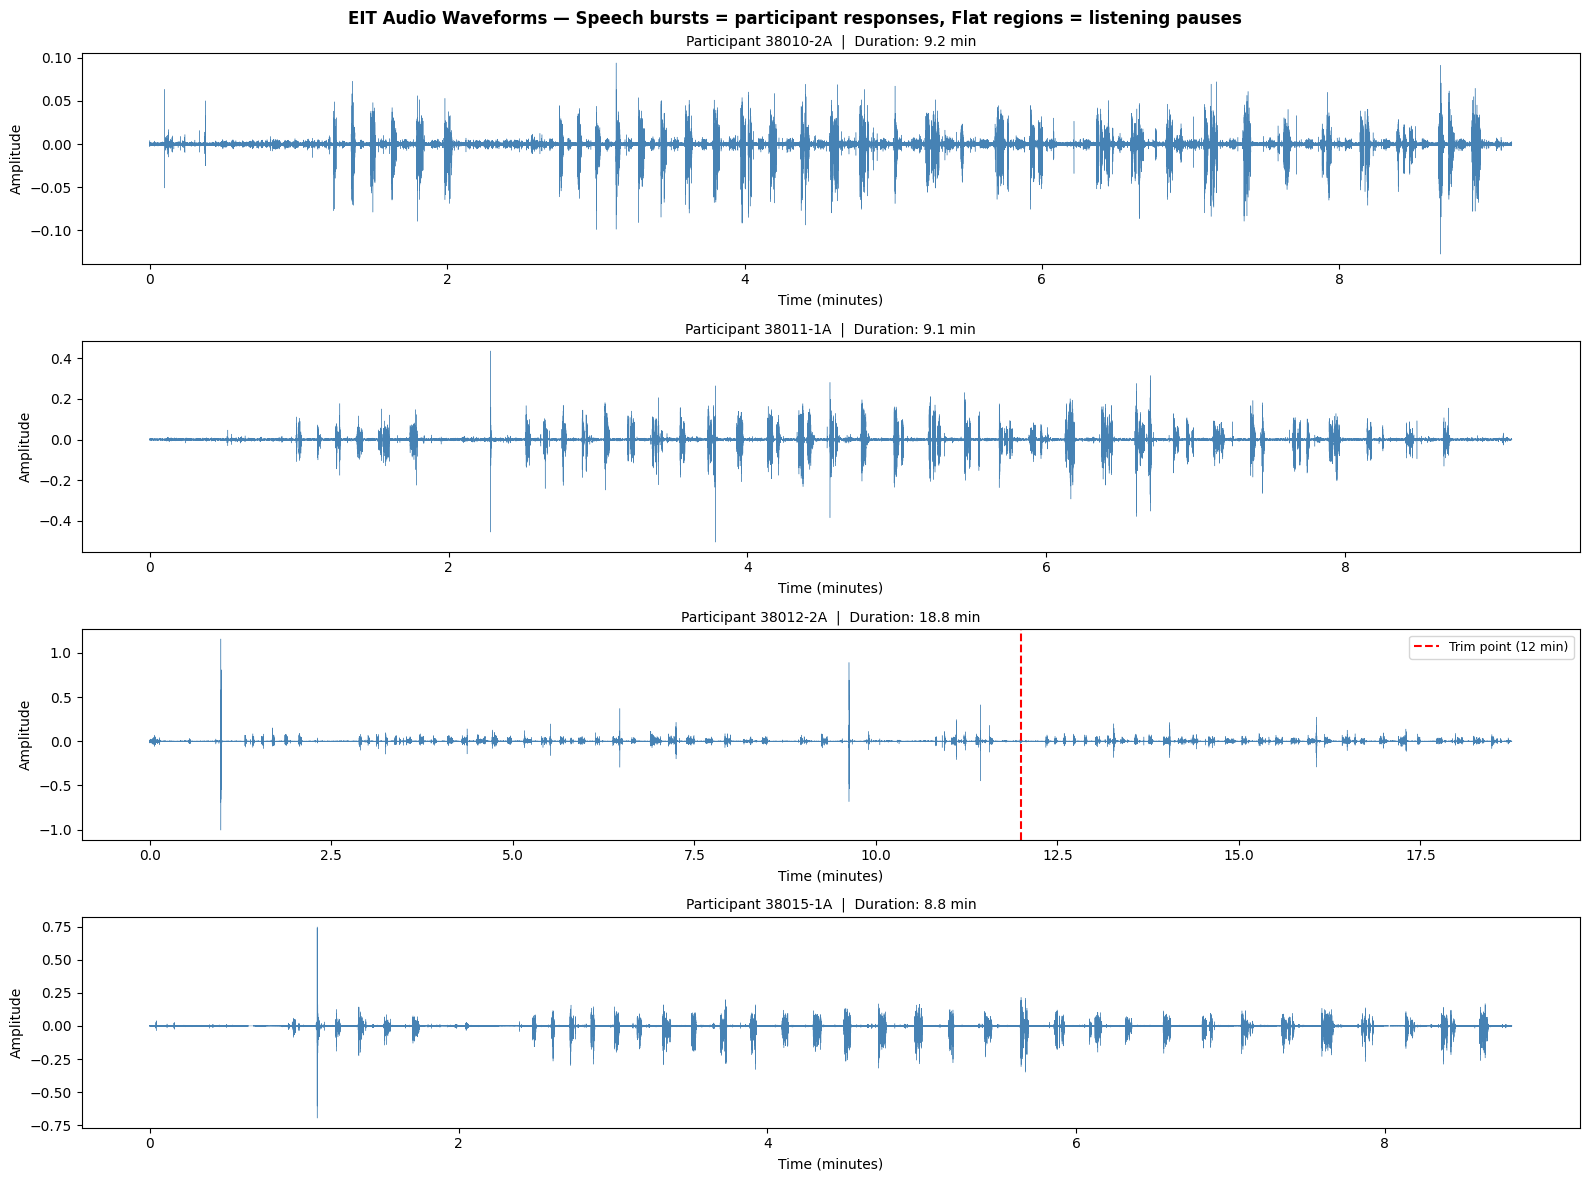

In [18]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle("EIT Audio Waveforms — Speech bursts = participant responses, Flat regions = listening pauses",
             fontsize=12, fontweight='bold')
for ax, (pid, audio_path) in zip(axes, PARTICIPANT_AUDIO.items()):
    if not os.path.exists(audio_path):
        ax.set_title(f"{pid} — FILE MISSING")
        continue
    # Load at reduced sample rate for speed (8kHz sufficient for inspection)
    y, sr = librosa.load(audio_path, sr=8000, mono=True)
    duration_min = librosa.get_duration(y=y, sr=sr) / 60
    times = np.linspace(0, duration_min, len(y))
    ax.plot(times, y, linewidth=0.3, color='steelblue')
    ax.set_title(f"Participant {pid}  |  Duration: {duration_min:.1f} min", fontsize=10)
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time (minutes)")
    # Mark the trim point for 38012-2A
    if pid == "38012-2A":
        trim_min = TRIM_START_MS[pid] / 60000
        ax.axvline(x=trim_min, color='red', linestyle='--', linewidth=1.5,
                   label=f'Trim point ({trim_min:.0f} min)')
        ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [19]:
##Trimming the 38012-2A file as relevant audio starts at 12:00
from pydub import AudioSegment
TRIMMED_AUDIO = dict(PARTICIPANT_AUDIO)
for pid, trim_ms in TRIM_START_MS.items():
    src = PARTICIPANT_AUDIO[pid]
    dst = os.path.join(BASE_DIR, f"{pid}_trimmed.mp3")
    if not os.path.exists(src):
        print(f"Skipping trim for {pid} — source file missing")
        continue
    print(f"Trimming {pid}: removing first {trim_ms/60000:.0f} minutes...")
    audio = AudioSegment.from_mp3(src)
    trimmed = audio[trim_ms:]
    trimmed.export(dst, format="mp3")
    original_min = len(audio) / 60000
    trimmed_min  = len(trimmed) / 60000
    print(f"  Original: {original_min:.1f} min  →  Trimmed: {trimmed_min:.1f} min")
    print(f"  Saved to: {dst}")
    TRIMMED_AUDIO[pid] = dst
print("\nTrim complete. TRIMMED_AUDIO paths:")
for pid, path in TRIMMED_AUDIO.items():
    print(f"  {pid}: {os.path.basename(path)}")

Trimming 38012-2A: removing first 12 minutes...
  Original: 18.8 min  →  Trimmed: 6.8 min
  Saved to: /content/AutoEIT/38012-2A_trimmed.mp3

Trim complete. TRIMMED_AUDIO paths:
  38010-2A: 038010_EIT-2A.mp3
  38011-1A: 038011_EIT-1A.mp3
  38012-2A: 38012-2A_trimmed.mp3
  38015-1A: 038015_EIT-1A.mp3


##  Load Whisper Model

### Model choice rationale

| Parameter | Value | Why |
|---|---|---|
| `model_size` | `medium` | Best WER/speed balance for Spanish on CPU. Use `large-v3` if T4/A100 GPU available. |
| `device` | `cuda` if available, else `cpu` | Auto-detects GPU in Colab |
| `compute_type` | `float16` (GPU) / `int8` (CPU) | int8 quantisation halves memory with <1% WER loss |
| `language` | `"es"` (locked) | Prevents misdetection as Portuguese or Catalan |
| `vad_filter` | `True` | Critical for EIT: skips long inter-sentence silence pauses |
| `vad_parameters` | `min_silence_duration_ms=1500` | EIT pauses are 2-5s; 1.5s threshold avoids splitting within a response |
| `beam_size` | `5` | Better than greedy (1); marginal improvement over 10 at lower cost |
| `word_timestamps` | `True` | Needed for alignment — gives us per-word timing |
| `temperature` | `0` | Deterministic; reproducible results |
| `initial_prompt` | Spanish EIT context | Biases decoder toward Spanish vocabulary and disfluency tokens |

In [20]:
import torch
from faster_whisper import WhisperModel
## Auto-detect GPU
if torch.cuda.is_available():
    DEVICE       = "cuda"
    COMPUTE_TYPE = "float16"
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    DEVICE       = "cpu"
    COMPUTE_TYPE = "int8"
    print("No GPU — using CPU with int8 quantisation (slower but works)")

MODEL_SIZE = "medium"

print(f"Loading Whisper '{MODEL_SIZE}' on {DEVICE} ({COMPUTE_TYPE})...")
model = WhisperModel(MODEL_SIZE, device=DEVICE, compute_type=COMPUTE_TYPE)
print("Model loaded successfully.")

GPU detected: Tesla T4
Loading Whisper 'medium' on cuda (float16)...
Model loaded successfully.


##  Core Transcription Functions

Three functions:
1. `transcribe_audio()` — calls Whisper and returns raw segments with timing
2. `chunk_by_silence()` — merges segments into utterances using pause gaps
3. `postprocess()` — preserves disfluencies, converts noise tokens to `[XXX]`

In [21]:
import re
# ── 1. Run Whisper ──────────────────────────────────────────────────────────
INITIAL_PROMPT = (
    "This audio contains a bilingual elicited imitation task. "
    "The participant repeats sentences in both English and Spanish. "
    "Transcribe exactly what is said including hesitations, false starts, "
    "and code-switching. Do not correct errors. "
    "El participante repite oraciones en inglés y español tal como las escucha."
)
def transcribe_audio(model, audio_path: str) -> list:
    """
    Run Whisper on a single audio file.
    Returns a list of segment objects, each with:
      .start, .end, .text, .avg_logprob, .no_speech_prob
    """
    segments, info = model.transcribe(
        audio_path,
        language_detection_segments=5,
        language_detection_threshold=0.5,
        initial_prompt=INITIAL_PROMPT,
        vad_filter=True,
        vad_parameters={"min_silence_duration_ms": 1500},
        condition_on_previous_text=False,
        no_speech_threshold=0.65,
        beam_size=5,
        word_timestamps=True,
        temperature=0,
    )
    # Materialise the generator (faster-whisper is lazy)
    result = list(segments)
    print(f"  Detected language: {info.language} (confidence: {info.language_probability:.2f})")
    print(f"  Raw segments from Whisper: {len(result)}")
    return result
# ── 2. Segment → Sentence Alignment ────────────────────────────────────────
def chunk_by_silence(segments: list, gap_threshold: float = 2.5) -> list:
    """
    Re-chunk Whisper segments into sentence-level utterances.

    Logic:
      - If gap between consecutive segments < gap_threshold seconds → merge (same utterance)
      - If gap >= gap_threshold → start a new utterance chunk

    gap_threshold=2.5s is chosen because:
      - EIT inter-sentence pauses (participant listening) are typically 4-8s
      - Within-sentence pauses/hesitations are rarely > 2s
    """
    if not segments:
        return []
    # Filter out Whisper hallucination artefacts (very short segments under 1 char)
    filtered = [s for s in segments if len(s.text.strip()) > 1]
    if not filtered:
        return []
    chunks = []
    buf = {
        "start": filtered[0].start,
        "end":   filtered[0].end,
        "text":  filtered[0].text.strip(),
        "avg_logprob":    filtered[0].avg_logprob,
        "no_speech_prob": filtered[0].no_speech_prob,
    }
    for seg in filtered[1:]:
        gap = seg.start - buf["end"]
        if gap < gap_threshold:
            # Same utterance — merge
            buf["text"] += " " + seg.text.strip()
            buf["end"]   = seg.end
            # Keep worst confidence scores (most conservative)
            buf["avg_logprob"]    = min(buf["avg_logprob"], seg.avg_logprob)
            buf["no_speech_prob"] = max(buf["no_speech_prob"], seg.no_speech_prob)
        else:
            chunks.append(buf)
            buf = {
                "start": seg.start,
                "end":   seg.end,
                "text":  seg.text.strip(),
                "avg_logprob":    seg.avg_logprob,
                "no_speech_prob": seg.no_speech_prob,
            }
    chunks.append(buf)
    return chunks
def align_to_slots(chunks: list, n: int = 30) -> list:
    """
    Map chunks to exactly n sentence slots in order.
    - If fewer chunks than n → fill remaining with [no response]
    - If more chunks than n → flag for manual review, truncate at n
    """
    slots = []
    for i in range(n):
        if i < len(chunks):
            slots.append(chunks[i])
        else:
            slots.append({"text": "[no response]", "avg_logprob": 0, "no_speech_prob": 1})
    if len(chunks) > n:
        print(f"WARNING: {len(chunks)} chunks found but only {n} slots — extra chunks dropped. Manual review needed.")
    return slots

# ── 3. Post-processing: preserve disfluencies ───────────────────────────────
def postprocess(text: str) -> str:
    """
    Clean up Whisper output while PRESERVING participant disfluencies.

    Rules (all from protocol):
      - Convert Whisper noise tokens [*], (*), [inaudible] → [XXX]
      - Preserve partial words ending with hyphen (false starts: "la-")
      - Preserve ellipsis for pauses (...)
      - Strip leading/trailing whitespace only
      - Do NOT remove or fix any Spanish grammar/vocabulary errors
    """
    if text in ("[no response]", "[audio missing]"):
        return text

    # Whisper noise/uncertain tokens → [XXX]
    text = re.sub(r'\[(?!no response)[^\]]+\]', '[XXX]', text)
    text = re.sub(r'\([^)]+\)', '[XXX]', text)
    text = re.sub(r' {2,}', ' ', text)
    return text.strip()

## Run Transcription for All 4 Participants

This cell loops over participants, calls Whisper, aligns to 30 slots, and stores results.

In [22]:
# Stores results: {participant_id: [{"text": ..., "flag": bool}, ...]}
ALL_TRANSCRIPTIONS = {}
for pid, audio_path in TRIMMED_AUDIO.items():
    print(f"\n{'='*60}")
    print(f"PARTICIPANT: {pid}  |  File: {os.path.basename(audio_path)}")
    print('='*60)

    if not os.path.exists(audio_path):
        print(f"Audio file not found — filling all slots with [audio missing]")
        ALL_TRANSCRIPTIONS[pid] = [
            {"text": "[audio missing]", "flag": False} for _ in range(N_SENTENCES)
        ]
        continue
    # Step 1: Whisper ASR
    raw_segments = transcribe_audio(model, audio_path)
    # Step 2: Merge segments into utterances by silence gap
    chunks = chunk_by_silence(raw_segments, gap_threshold=2.5)
    print(f"  Utterance chunks after silence-gap merging: {len(chunks)}")
    # Step 3: Map to 30 sentence slots
    slots = align_to_slots(chunks, n=N_SENTENCES)
    # Step 4: Post-process + flag low-confidence
    results = []
    n_flagged = 0
    for slot in slots:
        clean_text = postprocess(slot["text"])
        results.append({"text": clean_text,
                        "logprob": slot.get("avg_logprob", 0),
                        "no_speech": slot.get("no_speech_prob", 0)})
    ALL_TRANSCRIPTIONS[pid] = results
    n_no_response = sum(1 for r in results if r["text"] == "[no response]")
    n_transcribed = N_SENTENCES - n_no_response
    print(f" Transcribed: {n_transcribed}/30  |  [no response]: {n_no_response}  |  Low-confidence flags: {n_flagged}")

print("\n\nAll participants processed.")


PARTICIPANT: 38010-2A  |  File: 038010_EIT-2A.mp3
  Detected language: en (confidence: 0.90)
  Raw segments from Whisper: 23
  Utterance chunks after silence-gap merging: 23
 Transcribed: 23/30  |  [no response]: 7  |  Low-confidence flags: 0

PARTICIPANT: 38011-1A  |  File: 038011_EIT-1A.mp3
  Detected language: en (confidence: 0.77)
  Raw segments from Whisper: 24
  Utterance chunks after silence-gap merging: 23
 Transcribed: 23/30  |  [no response]: 7  |  Low-confidence flags: 0

PARTICIPANT: 38012-2A  |  File: 38012-2A_trimmed.mp3
  Detected language: es (confidence: 0.71)
  Raw segments from Whisper: 17
  Utterance chunks after silence-gap merging: 16
 Transcribed: 16/30  |  [no response]: 14  |  Low-confidence flags: 0

PARTICIPANT: 38015-1A  |  File: 038015_EIT-1A.mp3
  Detected language: en (confidence: 0.97)
  Raw segments from Whisper: 30
  Utterance chunks after silence-gap merging: 27
 Transcribed: 27/30  |  [no response]: 3  |  Low-confidence flags: 0


All participants p

In [23]:
import shutil
import openpyxl
from openpyxl.styles import Font, Alignment
from google.colab import files
import os
if 'BASE_DIR' not in globals():
    BASE_DIR = '/content/AutoEIT'
os.makedirs(BASE_DIR, exist_ok=True)
print("please upload your Excel template file now.")
uploaded_excel = files.upload()
excel_filename = list(uploaded_excel.keys())[0]
EXCEL_TEMPLATE = os.path.join(BASE_DIR, excel_filename)
with open(EXCEL_TEMPLATE, 'wb') as f:
    f.write(uploaded_excel[excel_filename])
print(f"Uploaded and saved: {excel_filename} to {BASE_DIR}")
OUTPUT_EXCEL   = os.path.join(BASE_DIR, "AutoEIT_Test1_Transcriptions_Completed.xlsx")
shutil.copy(EXCEL_TEMPLATE, OUTPUT_EXCEL)
wb = openpyxl.load_workbook(OUTPUT_EXCEL)
for pid, results in ALL_TRANSCRIPTIONS.items():
    if pid not in wb.sheetnames:
        print(f"Sheet '{pid}' not found in workbook — skipped")
        continue
    ws = wb[pid]
    for i, res in enumerate(results, start=2):
        cell = ws.cell(row=i, column=3)
        cell.value = res["text"]
        cell.alignment = Alignment(wrap_text=True, vertical="top")
        cell.font = Font(name="Arial", size=10)
    ws.column_dimensions["A"].width = 10
    ws.column_dimensions["B"].width = 52
    ws.column_dimensions["C"].width = 52
    print(f"  Written: {pid}")
wb.save(OUTPUT_EXCEL)
print(f"\nSaved → {OUTPUT_EXCEL}")

please upload your Excel template file now.


Saving AutoEIT Sample Audio for Transcribing.xlsx to AutoEIT Sample Audio for Transcribing (3).xlsx
Uploaded and saved: AutoEIT Sample Audio for Transcribing (3).xlsx to /content/AutoEIT
  Written: 38010-2A
  Written: 38011-1A
  Written: 38012-2A
  Written: 38015-1A

Saved → /content/AutoEIT/AutoEIT_Test1_Transcriptions_Completed.xlsx


## Challenges & Limitations

| Challenge | Source in Protocol | How Handled |
|---|---|---|
| Long inter-sentence silences | EIT task design | VAD filter (`min_silence=1500ms`) |
| 12-min preamble in `038012-2A` | Excel note | `pydub` trim before ASR |
| False starts (`la-`) | Protocol rule 2c | `postprocess()` preserves trailing hyphens |
| Pauses (`...`) | Protocol rule 2b | Preserved; not stripped by post-processing |
| English intrusions | Protocol rule 2d | Language-locked to `"es"` may transliterate; manual review of output is recommended |
| Unintelligible (`[XXX]`) | Protocol rule 2b | Whisper noise tokens → `[XXX]` |
| No response | Protocol rule 2h | Slots with no audio chunk → `[no response]` |
| Participant responds before tone | Protocol exception 1 | Alignment takes first chunk per gap window, includes early starts |
| `Lo` vs `La`, accent marks | Protocol rule 2a | `medium` model handles these well; manual review of output is recommended |
| Alignment drift (>30 or <30 chunks) | ASR + EIT structure | Diagnostic printed; manual review of output is recommended if chunk count is not 30 |

### What to do if alignment is wrong
If a participant produces <30 chunks, it usually means:
- Some responses were too short for VAD to detect → lower `min_silence_duration_ms` to 800ms
- Some responses merged with adjacent silence → increase `gap_threshold` to 3.5s.